# Chương 11-Demo

Notebook này minh họa các ý quan trọng trong **Chapter 11 - Deep learning for text** của sách *Deep Learning with Python, 2nd Edition*.

Mục tiêu:

- Hiểu pipeline biến **văn bản thô** thành **tensor số**.
- Thử các biểu diễn **bag-of-words**, **n-gram**, **count**, **TF-IDF**.
- Quan sát **word embedding**, **padding**, **masking**.
- Minh họa **self-attention**, **multi-head attention**, **positional embedding**.
- Hiểu template **sequence-to-sequence** và **causal mask** trong decoder.

Notebook dùng dữ liệu toy nhỏ bằng tiếng Việt/Anh để chạy nhanh trên lớp. Khi làm bài toán thật, ta thay dữ liệu toy bằng dataset lớn như IMDB hoặc tập dịch máy.

## 0. Chuẩn bị môi trường và font tiếng Việt

Ta dùng `tensorflow.keras` giống tinh thần trong sách, kết hợp `numpy`, `pandas`, `matplotlib` để hiển thị kết quả.

Phần font bên dưới giúp các biểu đồ Matplotlib hiển thị tiếng Việt tốt hơn trên Windows/Jupyter.

In [1]:
# Ẩn bớt log TensorFlow để output notebook gọn hơn.
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Các thư viện chuẩn dùng cho regex, xử lý chuỗi và chuẩn hóa Unicode.
import re
import string
import unicodedata

# Các thư viện tính toán, bảng dữ liệu và vẽ biểu đồ.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# TensorFlow/Keras dùng để minh họa các layer xử lý văn bản trong Chapter 11.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# Cố định seed để kết quả demo ổn định hơn giữa các lần chạy.
np.random.seed(42)
tf.random.set_seed(42)

# Ưu tiên các font có hỗ trợ tiếng Việt. Nếu máy không có font đầu tiên,
# Matplotlib sẽ dùng font tiếp theo trong danh sách.
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Arial", "Tahoma", "Segoe UI", "DejaVu Sans"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

# Giữ dấu trừ hiển thị đúng khi dùng font Unicode.
plt.rcParams["axes.unicode_minus"] = False

print("TensorFlow:", tf.__version__)
print("Matplotlib font:", plt.rcParams["font.family"])
print("Kiểm tra tiếng Việt: Học sâu cho văn bản - Chuẩn hóa, token hóa, chú ý.")

I0000 00:00:1782301617.494052   88770 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782301619.231566   88770 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Matplotlib font: ['Arial']
Kiểm tra tiếng Việt: Học sâu cho văn bản - Chuẩn hóa, token hóa, chú ý.


## 11.1 NLP: nhìn toàn cảnh

Trong chương này, NLP được xem như **pattern recognition applied to text**: mô hình không thật sự “hiểu như con người”, nhưng học được các **regularities** trong từ, câu và đoạn văn.

Ví dụ đơn giản: trong bài toán phân loại cảm xúc phim, các cụm như `rất hay`, `đáng xem`, `nhàm chán`, `thất vọng` thường liên quan mạnh đến nhãn positive/negative.

In [2]:
# Dataset toy gồm câu review phim và nhãn cảm xúc:
# 1 = positive, 0 = negative.
reviews = [
    ("Phim này rất hay và đáng xem", 1),
    ("Diễn viên xuất sắc, câu chuyện cảm động", 1),
    ("Tôi thích bộ phim này", 1),
    ("Phim quá dở và nhàm chán", 0),
    ("Diễn viên tệ, kịch bản rời rạc", 0),
    ("Tôi không thích bộ phim này", 0),
]

# Đưa dữ liệu vào DataFrame để sinh viên dễ quan sát.
pd.DataFrame(reviews, columns=["text", "label"])

,text,label
0,Phim này rất hay và đáng xem,1
1,"Diễn viên xuất sắc, câu chuyện cảm động",1
2,Tôi thích bộ phim này,1
3,Phim quá dở và nhàm chán,0
4,"Diễn viên tệ, kịch bản rời rạc",0
5,Tôi không thích bộ phim này,0


## 11.2 Chuẩn bị dữ liệu văn bản

Pipeline cơ bản:

```text
raw text -> standardization -> tokenization -> indexing -> vector encoding
```

Các bước này quyết định mô hình sẽ thấy thông tin nào và bỏ qua thông tin nào.

### 11.2.1 Text standardization - Chuẩn hóa văn bản

Chuẩn hóa giúp xóa các khác biệt ký tự không cần thiết, ví dụ:

- Chữ hoa/chữ thường.
- Dấu câu.
- Dấu tiếng hoặc biến thể Unicode.

Lưu ý: chuẩn hóa quá mạnh cũng có thể làm mất thông tin. Ví dụ dấu chấm than `!!!` đôi khi hữu ích trong sentiment analysis.

In [3]:
def remove_accents(text):
    """Bỏ dấu Unicode khỏi chuỗi văn bản.

    Tham số:
        text (str): Chuỗi đầu vào có thể chứa ký tự có dấu.

    Trả về:
        str: Chuỗi đã bỏ dấu, ví dụ "México" thành "Mexico".
    """
    # Tách ký tự có dấu thành ký tự gốc và dấu phụ theo chuẩn Unicode NFD.
    normalized = unicodedata.normalize("NFD", text)

    # Loại bỏ các dấu phụ có category là "Mn" (Mark, Nonspacing).
    return "".join(ch for ch in normalized if unicodedata.category(ch) != "Mn")


def standardize_text(text, strip_accents=True):
    """Chuẩn hóa văn bản trước khi tokenization.

    Tham số:
        text (str): Chuỗi văn bản đầu vào.
        strip_accents (bool): Nếu True, bỏ dấu Unicode trước khi bỏ dấu câu.

    Trả về:
        str: Chuỗi đã chuyển chữ thường, bỏ dấu câu và chuẩn hóa khoảng trắng.
    """
    # Chuyển về chữ thường để "Phim" và "phim" được xem là cùng một token.
    text = text.lower()

    # Tùy chọn bỏ dấu để giảm khác biệt Unicode giữa các cách viết.
    if strip_accents:
        text = remove_accents(text)

    # Loại bỏ punctuation như ".", "!", "?".
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    # Gộp nhiều khoảng trắng liên tiếp thành một khoảng trắng.
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Một vài câu ví dụ để thấy tác dụng của bước standardization.
sentences = [
    "Sunset came. I was staring at the México sky. Isn't nature splendid??",
    "sunset came; i stared at the Mexico sky. Isnt nature splendid?",
    "Phim này RẤT hay!!!",
]

for s in sentences:
    print("Gốc       :", s)
    print("Chuẩn hóa :", standardize_text(s))
    print()

Gốc       : Sunset came. I was staring at the México sky. Isn't nature splendid??
Chuẩn hóa : sunset came i was staring at the mexico sky isnt nature splendid

Gốc       : sunset came; i stared at the Mexico sky. Isnt nature splendid?
Chuẩn hóa : sunset came i stared at the mexico sky isnt nature splendid

Gốc       : Phim này RẤT hay!!!
Chuẩn hóa : phim nay rat hay



### 11.2.2 Tokenization - Tách token

Token có thể là:

- **word token**: tách theo từ.
- **N-gram**: nhóm token liên tiếp, ví dụ bigram.
- **character/subword token**: hữu ích khi nhiều từ hiếm hoặc nhiều lỗi chính tả.

In [4]:
def tokenize_words(text):
    """Tách văn bản thành danh sách word token.

    Tham số:
        text (str): Chuỗi văn bản đầu vào.

    Trả về:
        list[str]: Danh sách token sau khi chuẩn hóa nhẹ và tách theo khoảng trắng.
    """
    # Không bỏ dấu tiếng Việt ở ví dụ này để giữ nguyên token tiếng Việt khi cần.
    return standardize_text(text, strip_accents=False).split()


def make_ngrams(tokens, n=2):
    """Tạo danh sách n-gram từ một danh sách token.

    Tham số:
        tokens (list[str]): Danh sách token đầu vào.
        n (int): Số token trong mỗi n-gram, mặc định là 2 để tạo bigram.

    Trả về:
        list[str]: Danh sách n-gram dạng chuỗi.
    """
    # Trượt một cửa sổ kích thước n trên danh sách token.
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


text = "The cat sat on the mat."
tokens = tokenize_words(text)
print("Tokens:", tokens)
print("Bigrams:", make_ngrams(tokens, n=2))

Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Bigrams: ['the cat', 'cat sat', 'sat on', 'on the', 'the mat']


### 11.2.3 Vocabulary indexing - Lập chỉ mục từ vựng

Sau khi có token, ta xây **vocabulary** từ tập train và gán mỗi token một số nguyên. Token ngoài vocabulary thường được ánh xạ thành **`[UNK]`**.

In [5]:
# Lấy riêng phần text từ dataset toy.
train_texts = [x for x, y in reviews]

# Xây vocabulary đơn giản bằng Python thuần.
# "" có index 0 để dùng cho padding; "[UNK]" có index 1 cho token lạ.
vocab = {"": 0, "[UNK]": 1}

# Duyệt qua từng câu và từng token để thêm token mới vào vocabulary.
for text in train_texts:
    for token in tokenize_words(text):
        if token not in vocab:
            vocab[token] = len(vocab)

print("Kích thước vocabulary:", len(vocab))
print(vocab)


def encode_tokens(text, vocab):
    """Mã hóa chuỗi văn bản thành danh sách chỉ số token.

    Tham số:
        text (str): Chuỗi văn bản cần mã hóa.
        vocab (dict[str, int]): Từ điển ánh xạ token sang chỉ số.

    Trả về:
        list[int]: Danh sách chỉ số; token lạ được ánh xạ về chỉ số của "[UNK]".
    """
    # Với mỗi token, lấy index trong vocab; nếu không có thì dùng [UNK].
    return [vocab.get(tok, vocab["[UNK]"]) for tok in tokenize_words(text)]


sample = "Tôi rất thích diễn viên mới"
print("Text:", sample)
print("Encoded:", encode_tokens(sample, vocab))

Kích thước vocabulary: 30
{'': 0, '[UNK]': 1, 'phim': 2, 'này': 3, 'rất': 4, 'hay': 5, 'và': 6, 'đáng': 7, 'xem': 8, 'diễn': 9, 'viên': 10, 'xuất': 11, 'sắc': 12, 'câu': 13, 'chuyện': 14, 'cảm': 15, 'động': 16, 'tôi': 17, 'thích': 18, 'bộ': 19, 'quá': 20, 'dở': 21, 'nhàm': 22, 'chán': 23, 'tệ': 24, 'kịch': 25, 'bản': 26, 'rời': 27, 'rạc': 28, 'không': 29}
Text: Tôi rất thích diễn viên mới
Encoded: [17, 4, 18, 9, 10, 1]


### 11.2.4 TextVectorization trong Keras

Trong thực tế, ta thường dùng layer **`TextVectorization`** để chuẩn hóa, token hóa, học vocabulary và vector hóa. Một số `output_mode` quan trọng:

- `int`: trả về chuỗi chỉ số token, dùng cho sequence model.
- `multi_hot`: bag-of-words dạng token có/không.
- `count`: đếm số lần xuất hiện.
- `tf_idf`: trọng số TF-IDF.

In [6]:
# TextVectorization học vocabulary và biến raw string thành chuỗi số nguyên.
text_vectorization = TextVectorization(
    max_tokens=30,              # Giới hạn vocabulary để demo dễ quan sát.
    output_mode="int",          # Trả về chuỗi token index.
    output_sequence_length=8,   # Padding/truncate để mọi câu dài 8 token.
)

# adapt() chỉ nên gọi trên dữ liệu train để tránh rò rỉ thông tin từ test.
text_vectorization.adapt(train_texts)

vocabulary = text_vectorization.get_vocabulary()
print("Vocabulary học bởi TextVectorization:")
print(vocabulary)

# Vector hóa một câu mới để thấy token lạ sẽ thành [UNK].
sample = tf.constant(["Tôi thích phim này nhưng nhạc phim lạ"])
encoded = text_vectorization(sample)
print("\nEncoded tensor:", encoded.numpy())

# Tạo bảng tra ngược index -> token để giải mã gần đúng.
inverse_vocab = dict(enumerate(vocabulary))
decoded = " ".join(inverse_vocab[int(i)] for i in encoded[0] if int(i) != 0)
print("Decoded gần đúng:", decoded)

Vocabulary học bởi TextVectorization:
['', '[UNK]', np.str_('phim'), np.str_('này'), np.str_('và'), np.str_('viên'), np.str_('tôi'), np.str_('thích'), np.str_('diễn'), np.str_('bộ'), np.str_('động'), np.str_('đáng'), np.str_('xuất'), np.str_('xem'), np.str_('tệ'), np.str_('sắc'), np.str_('rời'), np.str_('rất'), np.str_('rạc'), np.str_('quá'), np.str_('nhàm'), np.str_('kịch'), np.str_('không'), np.str_('hay'), np.str_('dở'), np.str_('cảm'), np.str_('câu'), np.str_('chán'), np.str_('chuyện'), np.str_('bản')]

Encoded tensor: [[6 7 2 3 1 1 2 1]]
Decoded gần đúng: tôi thích phim này [UNK] [UNK] phim [UNK]


E0000 00:00:1782301623.099869   88770 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 11.3 Hai cách biểu diễn nhóm từ: tập và chuỗi

Câu hỏi trung tâm: mô hình có cần biết **thứ tự từ** không?

- **Bag-of-words** bỏ qua thứ tự, xem văn bản như tập/histogram token.
- **Sequence model** giữ thứ tự token, dùng RNN, 1D convnet hoặc Transformer.

### Bag-of-words: unigram, bigram, count và TF-IDF

Ta dùng cùng một câu nhưng thay đổi `TextVectorization` để thấy vector đầu ra khác nhau như thế nào.

In [7]:
# Corpus nhỏ dùng để so sánh các output_mode của TextVectorization.
demo_corpus = [
    "phim này rất hay",
    "phim này rất dở",
    "tôi không thích phim này",
    "tôi rất thích phim này",
]

sample = tf.constant(["tôi rất thích phim này"])

# Mỗi cấu hình thể hiện một cách biểu diễn văn bản khác nhau.
configs = {
    "multi_hot unigram": TextVectorization(max_tokens=20, output_mode="multi_hot"),
    "count unigram": TextVectorization(max_tokens=20, output_mode="count"),
    "multi_hot bigram": TextVectorization(max_tokens=20, output_mode="multi_hot", ngrams=2),
    "tf_idf bigram": TextVectorization(max_tokens=20, output_mode="tf_idf", ngrams=2),
}

for name, layer in configs.items():
    # Học vocabulary và thống kê cần thiết, ví dụ IDF cho tf_idf.
    layer.adapt(demo_corpus)

    # Vector hóa câu mẫu.
    vec = layer(sample).numpy()[0]
    vocab_layer = layer.get_vocabulary()

    # Chỉ in các chiều có giá trị dương để output ngắn và dễ đọc.
    active = [(vocab_layer[i], round(float(vec[i]), 3)) for i in np.where(vec > 0)[0]]
    print("\n==", name, "==")
    print(active)


== multi_hot unigram ==
[(np.str_('phim'), 1.0), (np.str_('này'), 1.0), (np.str_('rất'), 1.0), (np.str_('tôi'), 1.0), (np.str_('thích'), 1.0)]

== count unigram ==
[(np.str_('phim'), 1.0), (np.str_('này'), 1.0), (np.str_('rất'), 1.0), (np.str_('tôi'), 1.0), (np.str_('thích'), 1.0)]

== multi_hot bigram ==
[(np.str_('phim này'), 1.0), (np.str_('phim'), 1.0), (np.str_('này'), 1.0), (np.str_('rất'), 1.0), (np.str_('tôi'), 1.0), (np.str_('thích phim'), 1.0), (np.str_('thích'), 1.0), (np.str_('tôi rất'), 1.0), (np.str_('rất thích'), 1.0)]

== tf_idf bigram ==
[(np.str_('phim này'), 0.588), (np.str_('phim'), 0.588), (np.str_('này'), 0.588), (np.str_('rất'), 0.693), (np.str_('tôi'), 0.847), (np.str_('thích phim'), 0.847), (np.str_('thích'), 0.847), (np.str_('tôi rất'), 1.099), (np.str_('rất thích'), 1.099)]


### Demo nhỏ: classifier bag-of-bigrams

Trong sách, bag-of-bigrams là baseline rất mạnh trên IMDB. Ở đây ta huấn luyện một model nhỏ trên dữ liệu toy để thấy cách đặt **TextVectorization bên trong model**, giúp model nhận trực tiếp raw string.

In [8]:
# Dataset toy lớn hơn một chút để huấn luyện classifier bag-of-bigrams.
texts = np.array([
    "phim này rất hay",
    "diễn viên xuất sắc",
    "kịch bản cảm động",
    "tôi thích bộ phim này",
    "âm nhạc tuyệt vời",
    "phim vui và cuốn hút",
    "hình ảnh đẹp",
    "kết thúc làm tôi hài lòng",
    "một tác phẩm đáng xem",
    "nội dung thông minh",
    "phim này rất dở",
    "diễn viên tệ",
    "kịch bản nhàm chán",
    "tôi không thích bộ phim này",
    "âm nhạc khó chịu",
    "phim dài và buồn ngủ",
    "hình ảnh xấu",
    "kết thúc làm tôi thất vọng",
    "một tác phẩm không đáng xem",
    "nội dung rời rạc",
], dtype=object)

# 10 câu đầu positive, 10 câu sau negative.
labels = np.array([1]*10 + [0]*10)

# Vectorizer nằm trong model để model nhận trực tiếp raw string.
bow_vectorizer = TextVectorization(
    max_tokens=100,
    ngrams=2,                 # Dùng unigram + bigram.
    output_mode="multi_hot",  # Bag-of-words dạng có/không.
)
bow_vectorizer.adapt(texts)

# Input là tensor string, mỗi phần tử là một câu review.
inputs = keras.Input(shape=(), dtype=tf.string)

# Biến raw string thành vector multi-hot rồi đưa qua Dense classifier.
x = bow_vectorizer(inputs)
x = layers.Dense(8, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
bow_model = keras.Model(inputs, outputs)

# Binary classification nên dùng binary_crossentropy và sigmoid.
bow_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Dataset rất nhỏ nên train nhiều epoch để minh họa model có thể học pattern.
history = bow_model.fit(texts, labels, epochs=80, verbose=0)
print("Train accuracy cuối:", round(history.history["accuracy"][-1], 3))

# Thử dự đoán trên vài câu mới.
new_reviews = np.array([
    "phim rất đáng xem",
    "tôi không thích diễn viên",
    "kịch bản thông minh và cảm động",
    "phim buồn ngủ và rời rạc",
], dtype=object)
probs = bow_model.predict(new_reviews, verbose=0).reshape(-1)

pd.DataFrame({
    "review": new_reviews,
    "P(positive)": np.round(probs, 3),
})

Train accuracy cuối: 1.0


,review,P(positive)
0,phim rất đáng xem,0.617
1,tôi không thích diễn viên,0.363
2,kịch bản thông minh và cảm động,0.774
3,phim buồn ngủ và rời rạc,0.448


### Sequence model: integer sequence -> embedding sequence

Với sequence model, đầu vào giữ thứ tự token:

```text
[x1, x2, ..., xT] -> Embedding -> [v1, v2, ..., vT]
```

Embedding biến mỗi chỉ số token thành một vector dense thấp chiều.

In [ ]:
# Vectorizer dạng int giữ thứ tự token để dùng cho sequence model.
seq_vectorizer = TextVectorization(
    max_tokens=50,
    output_mode="int",
    output_sequence_length=8,
)
seq_vectorizer.adapt(texts)

# Mã hóa 3 câu đầu thành ma trận integer shape (batch, sequence_length).
encoded_batch = seq_vectorizer(tf.constant(texts[:3]))
print("Encoded batch shape:", encoded_batch.shape)
print(encoded_batch.numpy())

# Embedding biến mỗi token index thành vector dense 6 chiều.
# mask_zero=True giúp token padding 0 được đánh dấu là vị trí cần bỏ qua.
embedding = layers.Embedding(input_dim=50, output_dim=6, mask_zero=True)
embedded_batch = embedding(encoded_batch)
print("Embedding output shape:", embedded_batch.shape)

# compute_mask() trả về True cho token thật và False cho padding.
mask = embedding.compute_mask(encoded_batch)
print("Mask shape:", mask.shape)
print(mask.numpy().astype(int))

Encoded batch shape: (3, 8)
[[ 2  4 14 49  0  0  0  0]
 [25 10 31 39  0  0  0  0]
 [20 27  1 28  0  0  0  0]]
Embedding output shape: (3, 8, 6)
Mask shape: (3, 8)
[[1 1 1 1 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 0 0 0 0]]


### Padding và masking

- **Padding** thêm số 0 để các sequence trong batch có cùng độ dài.
- **Masking** báo cho layer sau biết vị trí nào là padding để bỏ qua.

Trong Keras, `Embedding(..., mask_zero=True)` tự tạo mask cho token 0.

In [10]:
# Ba câu có độ dài khác nhau để minh họa padding và masking.
examples = tf.constant([
    "phim hay",
    "tôi không thích bộ phim này",
    "diễn viên xuất sắc",
])

# TextVectorization thêm padding 0 để các câu có cùng chiều dài.
encoded = seq_vectorizer(examples)
mask = embedding.compute_mask(encoded)

# Tensor string khi chuyển sang numpy là bytes, nên cần decode UTF-8 rõ ràng.
pd.DataFrame({
    "text": [item.decode("utf-8") for item in examples.numpy()],
    "encoded": list(encoded.numpy()),
    "mask": list(mask.numpy().astype(int)),
})

,text,encoded,mask
0,phim hay,"[2, 49, 0, 0, 0, 0, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0]"
1,tôi không thích bộ phim này,"[3, 22, 13, 26, 2, 4, 0, 0]","[1, 1, 1, 1, 1, 1, 0, 0]"
2,diễn viên xuất sắc,"[25, 10, 31, 39, 0, 0, 0, 0]","[1, 1, 1, 1, 0, 0, 0, 0]"


## 11.4 Kiến trúc Transformer

Transformer dựa trên **attention**. Ý tưởng: không phải mọi token đều quan trọng như nhau đối với token đang xét; mô hình học cách “chú ý” đến các token liên quan.

### Self-attention bằng NumPy

Với mỗi token đang xét, ta tính điểm liên quan với mọi token khác, chuẩn hóa bằng softmax, rồi lấy tổng có trọng số của các vector token.

Công thức phổ biến:

$$
A(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In [11]:
def softmax(x):
    """Tính softmax cho một vector điểm số.

    Tham số:
        x (np.ndarray): Vector điểm số attention chưa chuẩn hóa.

    Trả về:
        np.ndarray: Vector xác suất có tổng bằng 1.
    """
    # Trừ max để tránh overflow khi tính exp.
    x = x - np.max(x)
    exp = np.exp(x)
    return exp / np.sum(exp)


sentence = ["the", "train", "left", "the", "station", "on", "time"]

# Vector toy 3 chiều. Cố tình cho "train" và "station" gần nhau
# để attention của "station" chú ý mạnh tới "train".
vectors = np.array([
    [0.1, 0.0, 0.0],  # the
    [0.9, 0.8, 0.1],  # train
    [0.2, 0.3, 0.8],  # left
    [0.1, 0.0, 0.0],  # the
    [0.8, 0.9, 0.1],  # station
    [0.1, 0.2, 0.2],  # on
    [0.2, 0.1, 0.7],  # time
], dtype="float32")

# Chọn token pivot là "station".
pivot_index = sentence.index("station")
pivot = vectors[pivot_index]

# Dot product đo mức liên quan giữa "station" và từng token khác.
scores = vectors @ pivot

# Chuẩn hóa scores thành attention weights.
weights = softmax(scores)

# Tạo vector mới cho "station" bằng tổng có trọng số của toàn bộ token vectors.
context_aware_vector = weights @ vectors

attention_table = pd.DataFrame({
    "token": sentence,
    "dot_score_with_station": np.round(scores, 3),
    "attention_weight": np.round(weights, 3),
})
print("Context-aware vector cho token 'station':", np.round(context_aware_vector, 3))
attention_table

Context-aware vector cho token 'station': [0.546 0.542 0.226]


,token,dot_score_with_station,attention_weight
0,the,0.08,0.072
1,train,1.45,0.282
2,left,0.51,0.110
3,the,0.08,0.072
4,station,1.46,0.285
5,on,0.28,0.088
6,time,0.32,0.091


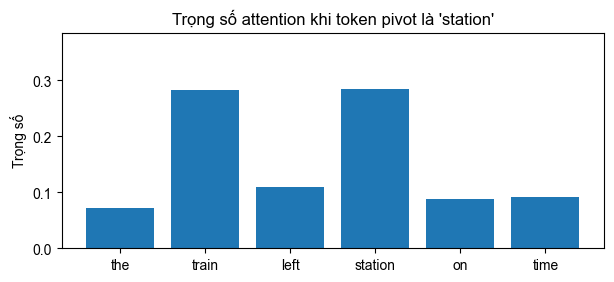

In [12]:
# Vẽ attention weights để sinh viên thấy token nào ảnh hưởng mạnh nhất tới "station".
plt.figure(figsize=(7, 2.8))
plt.bar(sentence, weights)
plt.title("Trọng số attention khi token pivot là 'station'")
plt.ylabel("Trọng số")
plt.ylim(0, max(weights) + 0.1)
plt.show()

### Multi-head attention trong Keras

Multi-head attention cho phép mô hình học nhiều “góc nhìn” khác nhau cùng lúc. Mỗi head có projection riêng cho Query, Key, Value.

In [13]:
# Tạo batch giả lập gồm 2 sequence, mỗi sequence có 5 token,
# mỗi token được biểu diễn bằng vector 16 chiều.
batch_size = 2
sequence_length = 5
embed_dim = 16

x = tf.random.normal(shape=(batch_size, sequence_length, embed_dim))

# MultiHeadAttention nhận query/key/value. Với self-attention,
# cả ba đều là cùng một tensor x.
mha = layers.MultiHeadAttention(num_heads=2, key_dim=embed_dim)
y = mha(query=x, value=x, key=x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : (2, 5, 16)
Output shape: (2, 5, 16)


### TransformerEncoder tối giản

Một encoder block thường gồm:

- `MultiHeadAttention`.
- Residual connection.
- `LayerNormalization`.
- Dense projection.

In [14]:
class TransformerEncoder(layers.Layer):
    """Transformer encoder block tối giản cho sequence representation.

    Khối này gồm MultiHeadAttention, residual connections,
    LayerNormalization và dense projection như mô tả trong Chapter 11.
    """

    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        """Khởi tạo các layer con của Transformer encoder.

        Tham số:
            embed_dim (int): Số chiều vector biểu diễn mỗi token.
            dense_dim (int): Số chiều ẩn trong dense projection.
            num_heads (int): Số attention heads.
            **kwargs: Tham số bổ sung cho lớp `layers.Layer`.
        """
        super().__init__(**kwargs)

        # Multi-head self-attention học tương tác giữa các token trong sequence.
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # Dense projection tăng khả năng biểu diễn sau attention.
        self.dense_proj = keras.Sequential([
            layers.Dense(dense_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])

        # LayerNorm giúp ổn định activation trong sequence model.
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        """Chạy forward pass của encoder block.

        Tham số:
            inputs (tf.Tensor): Tensor shape `(batch, sequence_length, embed_dim)`.
            mask (tf.Tensor | None): Mask đánh dấu token thật/padding nếu có.

        Trả về:
            tf.Tensor: Sequence representation sau attention và dense projection.
        """
        # MultiHeadAttention cần attention_mask có thêm trục head/query.
        if mask is not None:
            mask = mask[:, tf.newaxis, :]

        # Self-attention: query, key, value đều là inputs.
        attention_output = self.attention(inputs, inputs, attention_mask=mask)

        # Residual connection + LayerNorm sau attention.
        proj_input = self.layernorm_1(inputs + attention_output)

        # Dense projection rồi tiếp tục residual connection + LayerNorm.
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)


encoder = TransformerEncoder(embed_dim=16, dense_dim=32, num_heads=2)
encoded = encoder(x)
print("TransformerEncoder output shape:", encoded.shape)

TransformerEncoder output shape: (2, 5, 16)


### Positional embedding

Self-attention tự thân không biết token đứng ở đầu, giữa hay cuối câu. Vì vậy Transformer cần thêm **thông tin vị trí**.

Một cách đơn giản:

$$
z_i = w_i + p_i
$$

Trong đó `w_i` là word embedding và `p_i` là positional embedding.

In [15]:
class PositionalEmbedding(layers.Layer):
    """Layer cộng token embedding với positional embedding.

    Transformer cần positional embedding vì self-attention tự thân
    không biết thứ tự token trong câu.
    """

    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        """Khởi tạo token embedding và position embedding.

        Tham số:
            sequence_length (int): Độ dài sequence tối đa.
            input_dim (int): Kích thước vocabulary.
            output_dim (int): Số chiều embedding.
            **kwargs: Tham số bổ sung cho lớp `layers.Layer`.
        """
        super().__init__(**kwargs)

        # Embedding cho token index; token 0 là padding nên bật mask_zero.
        self.token_embeddings = layers.Embedding(input_dim=input_dim, output_dim=output_dim, mask_zero=True)

        # Embedding cho vị trí 0, 1, 2, ..., sequence_length - 1.
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        """Tạo embedding có thông tin vị trí.

        Tham số:
            inputs (tf.Tensor): Tensor token index shape `(batch, sequence_length)`.

        Trả về:
            tf.Tensor: Tensor embedding shape `(batch, sequence_length, output_dim)`.
        """
        # Lấy độ dài thực tế của sequence trong batch hiện tại.
        length = tf.shape(inputs)[-1]

        # Tạo vector vị trí [0, 1, ..., length - 1].
        positions = tf.range(start=0, limit=length, delta=1)

        # Tra embedding cho token và cho vị trí.
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)

        # Cộng hai embedding để mỗi token biết thêm thông tin vị trí.
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        """Tạo mask để bỏ qua token padding.

        Tham số:
            inputs (tf.Tensor): Tensor token index, trong đó 0 là padding.
            mask (tf.Tensor | None): Mask đầu vào nếu có, không dùng trong demo này.

        Trả về:
            tf.Tensor: Boolean mask, True cho token thật và False cho padding.
        """
        return tf.math.not_equal(inputs, 0)


pos_layer = PositionalEmbedding(sequence_length=8, input_dim=50, output_dim=6)
pos_output = pos_layer(encoded_batch)
print("Input integer sequence shape:", encoded_batch.shape)
print("Positional embedding output shape:", pos_output.shape)

Input integer sequence shape: (3, 8)
Positional embedding output shape: (3, 8, 6)


### Causal mask trong decoder

Khi decoder sinh token thứ `i`, nó **không được nhìn các token tương lai** `i+1, i+2, ...`.

Causal mask chặn attention tới tương lai, giúp training giống điều kiện inference.

[[1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1]]


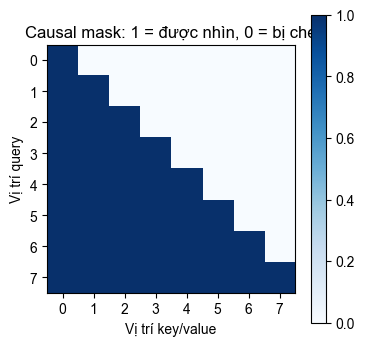

In [16]:
def causal_attention_mask(size):
    """Tạo causal mask cho Transformer decoder.

    Tham số:
        size (int): Độ dài sequence target.

    Trả về:
        tf.Tensor: Ma trận shape `(size, size)`, giá trị 1 cho vị trí được nhìn
        và 0 cho vị trí tương lai bị che.
    """
    # i là vị trí query hiện tại, j là vị trí key/value mà query muốn nhìn.
    i = tf.range(size)[:, tf.newaxis]
    j = tf.range(size)[tf.newaxis, :]

    # Chỉ cho phép nhìn chính nó và quá khứ: j <= i.
    return tf.cast(i >= j, dtype="int32")


mask = causal_attention_mask(8).numpy()
print(mask)

# Vẽ mask để thấy tam giác dưới là vùng được phép attention.
plt.figure(figsize=(4, 4))
plt.imshow(mask, cmap="Blues")
plt.title("Causal mask: 1 = được nhìn, 0 = bị che")
plt.xlabel("Vị trí key/value")
plt.ylabel("Vị trí query")
plt.xticks(range(8))
plt.yticks(range(8))
plt.colorbar()
plt.show()

## 11.5 Sequence-to-sequence learning

Sequence-to-sequence model nhận một chuỗi đầu vào và sinh một chuỗi đầu ra.

Ví dụ:

- Dịch máy: English sentence -> Spanish sentence.
- Tóm tắt văn bản: long document -> short summary.
- Chatbot: conversation history -> next reply.

Template chung: **encoder** xử lý source sequence, **decoder** sinh target sequence.

### Teacher forcing: target lệch một bước

Trong training seq2seq, decoder nhận target đã biết nhưng bị lệch một bước:

```text
Decoder input : [start] qué tiempo hace hoy
Target output : qué tiempo hace hoy [end]
```

Như vậy model học dự đoán token tiếp theo.

In [17]:
# Các cặp câu song ngữ toy để minh họa bài toán sequence-to-sequence.
pairs = [
    ("how is the weather today", "qué tiempo hace hoy"),
    ("i like this movie", "me gusta esta película"),
    ("she can play piano", "ella puede tocar piano"),
    ("this book is good", "este libro es bueno"),
]

# Tách source và target.
source_texts = [src for src, tgt in pairs]

# Thêm token bắt đầu/kết thúc để decoder biết khi nào bắt đầu và dừng.
target_texts = ["[start] " + tgt + " [end]" for src, tgt in pairs]

# Với target Spanish, giữ lại dấu [ ] trong [start]/[end],
# nhưng bỏ các punctuation khác để đơn giản hóa demo.
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "").replace("]", "")


def custom_standardization(input_string):
    """Chuẩn hóa chuỗi target Spanish cho TextVectorization.

    Tham số:
        input_string (tf.Tensor): Tensor chuỗi đầu vào.

    Trả về:
        tf.Tensor: Chuỗi đã lower-case và bỏ punctuation không cần thiết.
    """
    # TextVectorization custom standardization cần dùng tf.strings để chạy trong graph.
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, f"[{re.escape(strip_chars)}]", "")


# Vectorizer riêng cho source và target vì hai ngôn ngữ có vocabulary khác nhau.
source_vectorization = TextVectorization(
    max_tokens=50,
    output_mode="int",
    output_sequence_length=8,
)
target_vectorization = TextVectorization(
    max_tokens=50,
    output_mode="int",
    output_sequence_length=9,
    standardize=custom_standardization,
)

# Học vocabulary cho từng ngôn ngữ.
source_vectorization.adapt(source_texts)
target_vectorization.adapt(target_texts)

# Vector hóa source và target.
source_encoded = source_vectorization(tf.constant(source_texts))
target_encoded = target_vectorization(tf.constant(target_texts))

# Teacher forcing: decoder input bỏ token cuối, target output bỏ token đầu.
decoder_inputs = target_encoded[:, :-1]
target_outputs = target_encoded[:, 1:]

print("source_encoded shape :", source_encoded.shape)
print("decoder_inputs shape :", decoder_inputs.shape)
print("target_outputs shape :", target_outputs.shape)

source_encoded shape : (4, 8)
decoder_inputs shape : (4, 8)
target_outputs shape : (4, 8)


In [18]:
# Lấy vocabulary target để giải mã index về token.
tgt_vocab = target_vectorization.get_vocabulary()
tgt_lookup = dict(enumerate(tgt_vocab))


def decode_ids(ids):
    """Giải mã danh sách token index của target thành chuỗi token.

    Tham số:
        ids (Iterable[int]): Danh sách hoặc tensor chứa token indices.

    Trả về:
        str: Chuỗi token đã bỏ padding 0.
    """
    # Bỏ padding 0 để chuỗi hiển thị gọn hơn.
    return " ".join(tgt_lookup[int(i)] for i in ids if int(i) != 0)


# Hiển thị rõ sự lệch một bước giữa decoder input và target output.
rows = []
for i in range(len(pairs)):
    rows.append({
        "source": source_texts[i],
        "target text": target_texts[i],
        "decoder input": decode_ids(decoder_inputs[i]),
        "target output": decode_ids(target_outputs[i]),
    })

pd.DataFrame(rows)

,source,target text,decoder input,target output
0,how is the weather today,[start] qué tiempo hace hoy [end],[start] qué tiempo hace hoy [end],qué tiempo hace hoy [end]
1,i like this movie,[start] me gusta esta película [end],[start] me gusta esta película [end],me gusta esta película [end]
2,she can play piano,[start] ella puede tocar piano [end],[start] ella puede tocar piano [end],ella puede tocar piano [end]
3,this book is good,[start] este libro es bueno [end],[start] este libro es bueno [end],este libro es bueno [end]


### Encoder-decoder Transformer: ý tưởng khối

Một Transformer seq2seq đầy đủ thường có:

- **Encoder**: đọc source sequence và tạo representation phụ thuộc ngữ cảnh.
- **Decoder self-attention**: đọc target prefix đã sinh.
- **Cross-attention**: decoder dùng Query từ target, còn Key/Value đến từ encoded source.
- **Causal mask**: ngăn decoder nhìn token tương lai.

Notebook này không huấn luyện mô hình dịch máy đầy đủ để tránh mất thời gian, nhưng các cell trên đã minh họa các thành phần cốt lõi.

In [19]:
# Minh họa shape của cross-attention trong decoder.
batch_size = 2
source_len = 6
target_len = 4
embed_dim = 16

# encoded_source là output của encoder sau khi đọc source sequence.
encoded_source = tf.random.normal((batch_size, source_len, embed_dim))

# target_prefix là phần target decoder đã có tại thời điểm hiện tại.
target_prefix = tf.random.normal((batch_size, target_len, embed_dim))

# Trong cross-attention, query đến từ target; key/value đến từ source đã encode.
cross_attention = layers.MultiHeadAttention(num_heads=2, key_dim=embed_dim)
decoder_context = cross_attention(
    query=target_prefix,
    key=encoded_source,
    value=encoded_source,
)

print("encoded_source shape :", encoded_source.shape)
print("target_prefix shape  :", target_prefix.shape)
print("cross-attention output shape:", decoder_context.shape)

encoded_source shape : (2, 6, 16)
target_prefix shape  : (2, 4, 16)
cross-attention output shape: (2, 4, 16)


## Tổng kết notebook

Những điểm chính cần nhớ từ Chapter 11:

1. Văn bản phải đi qua **standardization**, **tokenization**, **indexing**, **vectorization** trước khi vào neural network.
2. **Bag-of-words / bag-of-bigrams** vẫn là baseline rất mạnh cho text classification.
3. **Word embeddings** biến token rời rạc thành vector dense có thể học được.
4. **Self-attention** tạo vector phụ thuộc ngữ cảnh bằng cách trộn thông tin từ các token liên quan.
5. Transformer cần **positional embedding** để biết thứ tự token.
6. **Sequence-to-sequence** dùng encoder-decoder để sinh chuỗi mới; decoder cần **causal mask** để không nhìn tương lai.